In [43]:
# Step 1: Import libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

In [44]:
# Step 2: Create a sample dataset (Loan applicants)
data = {
    'Income': [40000, 60000, 35000, 80000, 120000, 20000, 50000, 30000, 90000, 100000],
    'Credit_Score': [650, 700, 600, 720, 750, 580, 690, 640, 710, 730],
    'Loan_Amount': [15000, 20000, 12000, 25000, 40000, 10000, 18000, 12000, 30000, 35000],
    'Employment_Years': [2, 5, 1, 6, 10, 0, 3, 1, 7, 9],
    'Approval_Status': ['Rejected', 'Approved', 'Rejected', 'Approved', 
                        'Approved', 'Rejected', 'Approved', 'Rejected', 
                        'Approved', 'Approved']
}

In [45]:
df = pd.DataFrame(data)

In [46]:
# Step 3: Features (X) and Target (y)
X = df[['Income', 'Credit_Score', 'Loan_Amount', 'Employment_Years']]
y = df['Approval_Status']

In [47]:
# Step 4: Split into Train and Test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.3, 
                                                    random_state=42)

In [48]:
# Step 5: Train Decision Tree Classifier
dt = DecisionTreeClassifier(max_depth=3, random_state=42)
dt.fit(X_train, y_train)

#low max depth (ex 2-3) - high bias and low variance - underfit, miss patterns, poor accuracy
#moderate max depth (ex 5-10) balanced bias and variance, good generalization
#high max depth (20+) low bias, high variance - overfits, memorizes training data, poor generalization

DecisionTreeClassifier(max_depth=3, random_state=42)

In [49]:
# Step 6: Make Predictions
y_pred = dt.predict(X_test)

In [50]:
print("Predictions:", y_pred.tolist())
print("Actual:", y_test.tolist())

Predictions: ['Approved', 'Approved', 'Rejected']
Actual: ['Approved', 'Approved', 'Rejected']


In [51]:
print("feature_names=", X.columns)
print("class_names=", dt.classes_)

feature_names= Index(['Income', 'Credit_Score', 'Loan_Amount', 'Employment_Years'], dtype='object')
class_names= ['Approved' 'Rejected']


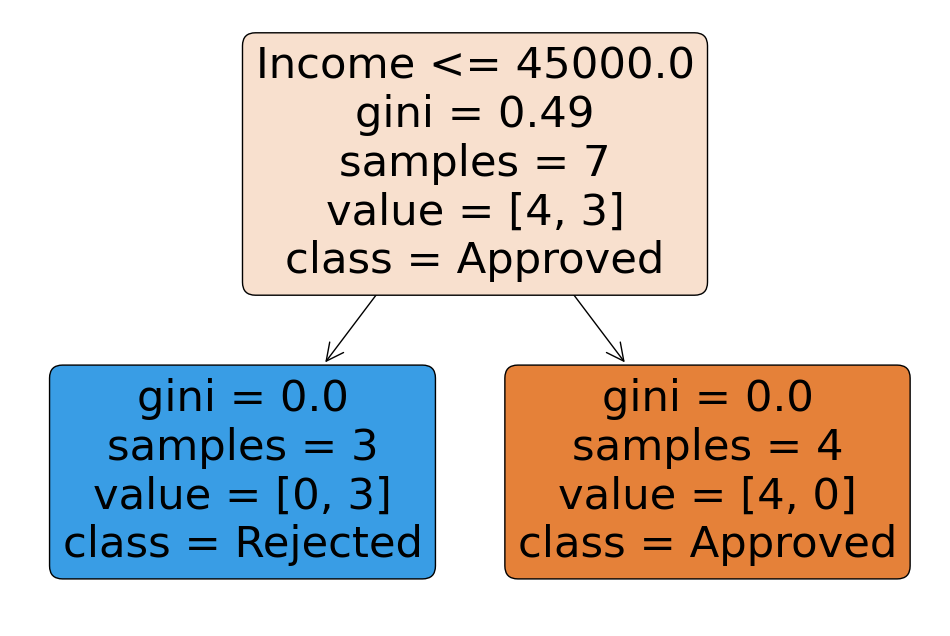

In [52]:
# Step 7: Visualize the Decision Tree
plt.figure(figsize=(12,8))
plot_tree(dt, feature_names=X.columns, class_names=dt.classes_, 
          filled=True, rounded=True)
plt.show()

In [ ]:
#split condition - if income <= 45000, go left otherwise right
#gini = 0.49 , moderate impurity 
#samples = 7 - total data points at this node
#value = [4,3] - 4 approvd, 3 rejected
#Left child
# gini 0.0
#value=[0,3] - 3 rejected - clear decision

#right child
#gini=0.0, samples =4
#value=[4,0]
#class - approved - all sampless are approved, clear decision

In [ ]:
#Gini impurity measures how mixed the classes are at a node in a decision tree.
#ex -
#assume jar of marbles
#All red - Gini = 0.0
#half red, half blue -uncertain-    Gini = 0.5
#more colors -> even more confusion , higher gini